# Attraction--repulsion parameter screening

This notebook performs a two-dimensional search over the switching distance \(\varepsilon\) and repulsion strength \(\rho\).

The notebook does **not** train either graph identifier. It first
searches for an environment regime in which targeted intervention
has a repeatable advantage over uniform allocation.

Policies:

- **no control**
- **uniform allocation**
- **static true-graph centrality**
- **one-step repulsion-aware oracle**

Static true-graph centrality is the primary selection policy. The one-step oracle diagnoses whether a setting is controllable at all. Settings with excessive time at the clipping boundaries are penalized in the ranking.


In [3]:

from __future__ import annotations

import inspect
import json
import math
import random
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Iterable, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find the repository root containing opinion_dynamics/. "
        "Place this notebook inside the repository or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_eigenvector_centrality,
    compute_laplacian,
)
from opinion_dynamics.baseline import centrality_based_continuous_control
from opinion_dynamics.utils.env_setup import EnvironmentFactory


REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration

Set `QUICK_RUN = True` for a one-graph, one-initial-state smoke test.

In [4]:

STUDY_DATE = "2026_07_28"
STUDY_NAME = "repulsion_parameter_screen"
RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

QUICK_RUN = False
FAIL_FAST = True

if QUICK_RUN:
    TOPOLOGY_SEEDS = [3]
    INITIAL_PERMUTATION_SEEDS = [0]
else:
    TOPOLOGY_SEEDS = [3, 4, 5]
    INITIAL_PERMUTATION_SEEDS = [0, 1, 2]

OMEGA = 1.0
U_BAR = 0.2
NUM_CAMPAIGNS_TOTAL = 20
T_CAMPAIGN = 0.5
T_S = 0.1
TOTAL_CONTROLLED_BUDGET = 6.0
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)
ZERO_FIRST_CAMPAIGN = True

INITIAL_STATE_SEED_BASE = 920_000
MIN_TARGET_WIN_RATE = 2.0 / 3.0
TOP_CONFIGS_TO_PLOT = 3
MAX_ACCEPTABLE_BOUNDARY_FRACTION = 0.35

POLICY_NOCONTROL = "no_control"
POLICY_UNIFORM = "uniform"
POLICY_STATIC = "true_graph_centrality"
POLICY_MODEL_AWARE = "model_aware"

POLICY_ORDER = [
    POLICY_NOCONTROL,
    POLICY_UNIFORM,
    POLICY_STATIC,
    POLICY_MODEL_AWARE,
]

MODEL_KIND = "repulsion"
MODEL_DISPLAY_NAME = "Attraction--repulsion"
DYNAMICS_MODEL = "repulsion"
STUDY_NAME = "repulsion_parameter_screen"

PARAM_COLUMNS = [
    "repulsion_epsilon",
    "repulsion_strength",
]
PARAMETER_LABELS = {
    "repulsion_epsilon": "switching distance epsilon",
    "repulsion_strength": "repulsion strength rho",
}

REPULSION_EPSILONS = [
    0.10,
    0.20,
    0.30,
    0.45,
]
REPULSION_STRENGTHS = [
    0.10,
    0.30,
    0.70,
    1.20,
]
PARAM_CONFIGS = [
    {
        "repulsion_epsilon": epsilon,
        "repulsion_strength": strength,
    }
    for epsilon in REPULSION_EPSILONS
    for strength in REPULSION_STRENGTHS
]

DIAGNOSTIC_COLUMNS = [
    "boundary_fraction",
    "attractive_edge_fraction",
    "repulsive_edge_fraction",
]

POLICY_LABELS = {
    POLICY_NOCONTROL: "no control",
    POLICY_UNIFORM: "uniform",
    POLICY_STATIC: "static true-graph centrality",
    POLICY_MODEL_AWARE: "one-step repulsion-aware oracle",
}

# Static true-graph centrality is the primary policy because it is closer to
# the control rule used after graph identification. The one-step oracle is a
# secondary controllability diagnostic.
PRIMARY_POLICY = POLICY_STATIC

print("Results directory:", RESULTS_DIR)
print("Configurations:", len(PARAM_CONFIGS))
print(
    "Rollouts:",
    len(PARAM_CONFIGS)
    * len(TOPOLOGY_SEEDS)
    * len(INITIAL_PERMUTATION_SEEDS)
    * len(POLICY_ORDER),
)
print("Campaign budget:", B_CAMPAIGN)


Results directory: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_repulsion_parameter_screen
Configurations: 16
Rollouts: 576
Campaign budget: 0.3157894736842105


## Environment, control, and diagnostic helpers

Every parameter setting and policy uses the same graph and initial opinion vector for a given paired trial.

In [5]:

def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)


def make_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    return rng.permutation(np.linspace(0.0, 1.0, int(n), dtype=float))


def copy_env_value(value: Any) -> Any:
    if isinstance(value, np.ndarray):
        return np.array(value, copy=True)
    if isinstance(value, list):
        return list(value)
    if isinstance(value, tuple):
        return tuple(value)
    return value


def filter_constructor_kwargs(
    env_class: type,
    kwargs: Dict[str, Any],
    *,
    required_keys: Iterable[str] = (),
) -> Dict[str, Any]:
    signature = inspect.signature(env_class.__init__)
    parameters = signature.parameters

    if any(
        parameter.kind == inspect.Parameter.VAR_KEYWORD
        for parameter in parameters.values()
    ):
        return dict(kwargs)

    accepted = {
        name
        for name, parameter in parameters.items()
        if name != "self"
        and parameter.kind
        in {
            inspect.Parameter.POSITIONAL_OR_KEYWORD,
            inspect.Parameter.KEYWORD_ONLY,
        }
    }

    missing_required = sorted(set(required_keys) - accepted)
    if missing_required:
        raise RuntimeError(
            "The installed NetworkGraph constructor does not support "
            f"{missing_required}. Update the local rl-envs-forge checkout."
        )

    return {key: value for key, value in kwargs.items() if key in accepted}


def make_topology_template(topology_seed: int) -> Any:
    factory = EnvironmentFactory()
    return factory.get_randomized_env(
        seed=int(topology_seed),
        dynamics_model="laplacian",
    )


def make_screening_env(
    topology_template: Any,
    x0: np.ndarray,
    config: Dict[str, float],
    *,
    topology_seed: int,
) -> Any:
    n = int(topology_template.num_agents)

    kwargs: Dict[str, Any] = {
        "connectivity_matrix": np.array(
            topology_template.connectivity_matrix,
            copy=True,
        ),
        "num_agents": n,
        "max_u": np.full(n, U_BAR, dtype=float),
        "desired_opinion": float(OMEGA),
        "t_campaign": float(T_CAMPAIGN),
        "t_s": float(T_S),
        "dynamics_model": DYNAMICS_MODEL,
        "initial_opinions": np.asarray(x0, dtype=float).copy(),
        "initial_opinion_range": tuple(
            getattr(topology_template, "initial_opinion_range", (0.0, 1.0))
        ),
        "control_resistance": np.array(
            getattr(
                topology_template,
                "control_resistance",
                np.zeros(n, dtype=float),
            ),
            copy=True,
        ),
        "max_steps": int(getattr(topology_template, "max_steps", 10_000)),
        "opinion_end_tolerance": float(
            getattr(topology_template, "opinion_end_tolerance", 0.01)
        ),
        "control_beta": float(
            getattr(topology_template, "control_beta", 0.4)
        ),
        "normalize_reward": bool(
            getattr(topology_template, "normalize_reward", False)
        ),
        "terminal_reward": float(
            getattr(topology_template, "terminal_reward", 0.0)
        ),
        "terminate_when_converged": False,
        "budget": copy_env_value(
            getattr(topology_template, "budget", None)
        ),
        "use_delta_shaping": bool(
            getattr(topology_template, "use_delta_shaping", False)
        ),
        "delta_lambda": float(
            getattr(topology_template, "delta_lambda", 0.0)
        ),
        "seed": int(topology_seed),
    }

    if MODEL_KIND == "fj":
        kwargs.update(
            {
                "fj_lambda": float(config["fj_lambda"]),
                # None means that the environment copies the initial state.
                "fj_prejudice": None,
            }
        )
        required_keys = {"fj_lambda", "fj_prejudice"}
    elif MODEL_KIND == "nonlinear":
        kwargs.update(
            {
                "nonlinear_beta": float(config["nonlinear_beta"]),
            }
        )
        required_keys = {"nonlinear_beta"}
    elif MODEL_KIND == "repulsion":
        kwargs.update(
            {
                "repulsion_epsilon": float(config["repulsion_epsilon"]),
                "repulsion_strength": float(config["repulsion_strength"]),
            }
        )
        required_keys = {
            "repulsion_epsilon",
            "repulsion_strength",
        }
    else:
        raise ValueError(f"Unsupported MODEL_KIND: {MODEL_KIND}")

    kwargs = filter_constructor_kwargs(
        topology_template.__class__,
        kwargs,
        required_keys=required_keys,
    )

    env = topology_template.__class__(**kwargs)
    env.reset()

    if not np.allclose(np.asarray(env.opinions, dtype=float), x0):
        raise RuntimeError("The environment did not reset to the requested x0.")

    if MODEL_KIND == "fj":
        if not np.allclose(
            np.asarray(env.fj_prejudice, dtype=float),
            x0,
        ):
            raise RuntimeError(
                "FJ prejudice is not equal to the trial initial opinion vector."
            )

    return env


def sanitize_centrality(
    centrality: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    v = np.asarray(centrality, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

    if float(v.sum()) < 0:
        v = -v

    v = np.maximum(v, 0.0)
    total = float(v.sum())

    if total <= eps:
        v = np.abs(v)
        total = float(v.sum())

    if total <= eps:
        return np.full(v.shape, 1.0 / len(v), dtype=float)

    return v / total


def centrality_from_matrix(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    return sanitize_centrality(
        compute_eigenvector_centrality(
            compute_laplacian(matrix)
        )
    )


def row_normalize(
    matrix: np.ndarray,
    fallback: np.ndarray | None = None,
    eps: float = 1e-12,
) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float).copy()
    row_sums = matrix.sum(axis=1, keepdims=True)

    if fallback is not None:
        fallback = np.asarray(fallback, dtype=float)
        zero_rows = np.flatnonzero(row_sums[:, 0] <= eps)
        for row in zero_rows:
            matrix[row] = fallback[row]
        row_sums = matrix.sum(axis=1, keepdims=True)

    zero_rows = np.flatnonzero(row_sums[:, 0] <= eps)
    for row in zero_rows:
        matrix[row, row] = 1.0

    row_sums = matrix.sum(axis=1, keepdims=True)
    return matrix / np.maximum(row_sums, eps)


def uniform_budget_action(
    max_u: np.ndarray,
    budget: float,
) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    action = np.zeros_like(max_u)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(max_u.size, dtype=bool)

    while remaining > 1e-12 and active.any():
        active_indices = np.flatnonzero(active)
        share = remaining / len(active_indices)
        progressed = False

        for index in active_indices:
            available = float(max_u[index] - action[index])
            allocation = min(share, available)

            if allocation > 0:
                action[index] += allocation
                remaining -= allocation
                progressed = True

            if action[index] >= max_u[index] - 1e-12:
                active[index] = False

        if not progressed:
            break

    return action


def one_step_greedy_action(
    env: Any,
    budget: float,
) -> np.ndarray:
    """Greedily allocate the current budget using the true one-step dynamics."""
    max_u = np.asarray(env.max_u, dtype=float).reshape(-1)
    action = np.zeros_like(max_u)
    remaining = min(float(budget), float(max_u.sum()))
    current_state = np.asarray(env.opinions, dtype=float).copy()

    while remaining > 1e-12:
        best_score = -np.inf
        best_candidate = None

        for node in range(env.num_agents):
            room = float(max_u[node] - action[node])
            if room <= 1e-12:
                continue

            candidate = action.copy()
            candidate[node] += min(remaining, room)

            predicted_state, _ = env.compute_dynamics(
                current_state,
                candidate,
            )
            score = -float(
                np.mean(
                    np.abs(
                        OMEGA
                        - np.asarray(predicted_state, dtype=float)
                    )
                )
            )

            if score > best_score:
                best_score = score
                best_candidate = candidate

        if best_candidate is None:
            break

        spent_before = float(action.sum())
        action = best_candidate
        spent_now = float(action.sum())
        remaining -= max(0.0, spent_now - spent_before)

    return action


def nonlinear_effective_matrix(
    adjacency: np.ndarray,
    opinions: np.ndarray,
    beta: float,
) -> np.ndarray:
    adjacency = np.asarray(adjacency, dtype=float)
    x = np.asarray(opinions, dtype=float).reshape(-1)
    diff = x[None, :] - x[:, None]

    gain = np.empty_like(diff)
    nonzero = np.abs(diff) > 1e-12
    gain[nonzero] = np.tanh(float(beta) * diff[nonzero]) / diff[nonzero]
    gain[~nonzero] = float(beta)

    effective = adjacency * np.maximum(gain, 0.0)
    return row_normalize(effective, fallback=adjacency)


def boundary_fraction(opinions: np.ndarray, tol: float = 1e-10) -> float:
    x = np.asarray(opinions, dtype=float).reshape(-1)
    return float(np.mean((x <= tol) | (x >= 1.0 - tol)))


def model_diagnostics(
    env: Any,
    config: Dict[str, float],
    opinions: np.ndarray,
) -> Dict[str, float]:
    x = np.asarray(opinions, dtype=float).reshape(-1)
    adjacency = np.asarray(env.connectivity_matrix, dtype=float)
    graph_edges = adjacency > 0

    diagnostics: Dict[str, float] = {
        "boundary_fraction": boundary_fraction(x),
    }

    if MODEL_KIND == "fj":
        prejudice = np.asarray(env.fj_prejudice, dtype=float)
        diagnostics["prejudice_distance"] = float(
            np.mean(np.abs(x - prejudice))
        )
        diagnostics["opinion_std"] = float(np.std(x))

    elif MODEL_KIND == "nonlinear":
        beta = float(config["nonlinear_beta"])
        diff = x[None, :] - x[:, None]
        edge_differences = diff[graph_edges]

        if edge_differences.size == 0:
            diagnostics["saturation_fraction"] = 0.0
            diagnostics["mean_abs_influence"] = 0.0
        else:
            transformed = np.tanh(beta * edge_differences)
            diagnostics["saturation_fraction"] = float(
                np.mean(np.abs(transformed) >= 0.95)
            )
            diagnostics["mean_abs_influence"] = float(
                np.mean(np.abs(transformed))
            )

    elif MODEL_KIND == "repulsion":
        epsilon = float(config["repulsion_epsilon"])
        diff = np.abs(x[None, :] - x[:, None])
        edge_distances = diff[graph_edges]

        if edge_distances.size == 0:
            attractive_fraction = 0.0
        else:
            attractive_fraction = float(
                np.mean(edge_distances <= epsilon)
            )

        diagnostics["attractive_edge_fraction"] = attractive_fraction
        diagnostics["repulsive_edge_fraction"] = 1.0 - attractive_fraction

    return diagnostics


## Rollout and metrics

In [6]:

def choose_action(
    env: Any,
    config: Dict[str, float],
    *,
    policy: str,
    static_centrality: np.ndarray,
) -> np.ndarray:
    max_u = np.asarray(env.max_u, dtype=float).reshape(-1)

    if policy == POLICY_NOCONTROL:
        return np.zeros(env.num_agents, dtype=float)

    if policy == POLICY_UNIFORM:
        return uniform_budget_action(max_u, B_CAMPAIGN)

    if policy == POLICY_STATIC:
        action, _ = centrality_based_continuous_control(
            env,
            B_CAMPAIGN,
            v=static_centrality,
        )
        return np.asarray(action, dtype=float)

    if policy == POLICY_MODEL_AWARE:
        if MODEL_KIND == "nonlinear":
            effective_matrix = nonlinear_effective_matrix(
                env.connectivity_matrix,
                env.opinions,
                config["nonlinear_beta"],
            )
            state_centrality = centrality_from_matrix(
                effective_matrix
            )
            action, _ = centrality_based_continuous_control(
                env,
                B_CAMPAIGN,
                v=state_centrality,
            )
            return np.asarray(action, dtype=float)

        return one_step_greedy_action(
            env,
            B_CAMPAIGN,
        )

    raise ValueError(f"Unknown policy: {policy}")


def run_policy_rollout(
    topology_template: Any,
    x0: np.ndarray,
    config: Dict[str, float],
    *,
    topology_seed: int,
    initial_seed: int,
    policy: str,
) -> Dict[str, Any]:
    env = make_screening_env(
        topology_template,
        x0,
        config,
        topology_seed=topology_seed,
    )

    adjacency = np.asarray(
        env.connectivity_matrix,
        dtype=float,
    )
    static_centrality = centrality_from_matrix(adjacency)

    states = [np.asarray(x0, dtype=float).copy()]
    actions: List[np.ndarray] = []
    rewards: List[float] = []
    diagnostics = [model_diagnostics(env, config, x0)]

    for campaign in range(NUM_CAMPAIGNS_TOTAL):
        if ZERO_FIRST_CAMPAIGN and campaign == 0:
            action = np.zeros(env.num_agents, dtype=float)
        else:
            action = choose_action(
                env,
                config,
                policy=policy,
                static_centrality=static_centrality,
            )

        x_next, reward, done, truncated, info = env.step(
            np.asarray(action, dtype=float)
        )

        x_next = np.asarray(x_next, dtype=float)
        states.append(x_next.copy())
        actions.append(np.asarray(action, dtype=float).copy())
        rewards.append(float(reward))
        diagnostics.append(
            model_diagnostics(env, config, x_next)
        )

        if done or truncated:
            break

    states_array = np.asarray(states, dtype=float)
    actions_array = np.asarray(actions, dtype=float)
    mean_trajectory = states_array.mean(axis=1)
    time_axis = (
        np.arange(states_array.shape[0], dtype=float)
        * T_CAMPAIGN
    )

    if time_axis[-1] > 0:
        time_average_mean = float(
            np.trapz(mean_trajectory, time_axis)
            / time_axis[-1]
        )
    else:
        time_average_mean = float(mean_trajectory[-1])

    final_state = states_array[-1]
    result: Dict[str, Any] = {
        **{name: float(config[name]) for name in PARAM_COLUMNS},
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "policy": policy,
        "states": states_array,
        "actions": actions_array,
        "rewards": np.asarray(rewards, dtype=float),
        "times": time_axis,
        "diagnostics": diagnostics,
        "final_mean": float(final_state.mean()),
        "time_average_mean": time_average_mean,
        "final_target_mae": float(
            np.mean(np.abs(OMEGA - final_state))
        ),
        "final_std": float(final_state.std()),
        "final_min": float(final_state.min()),
        "final_max": float(final_state.max()),
        "total_reward": float(np.sum(rewards)),
    }

    for diagnostic_name in DIAGNOSTIC_COLUMNS:
        values = [
            float(item[diagnostic_name])
            for item in diagnostics
        ]
        result[f"initial_{diagnostic_name}"] = values[0]
        result[f"mean_{diagnostic_name}"] = float(np.mean(values))
        result[f"final_{diagnostic_name}"] = values[-1]

    return result


def scalar_trial_row(
    rollout: Dict[str, Any],
) -> Dict[str, Any]:
    excluded = {
        "states",
        "actions",
        "rewards",
        "times",
        "diagnostics",
    }
    return {
        key: value
        for key, value in rollout.items()
        if key not in excluded
    }


def trajectory_rows(
    rollout: Dict[str, Any],
) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []

    for boundary_index, (
        time_value,
        state,
        diagnostic,
    ) in enumerate(
        zip(
            rollout["times"],
            rollout["states"],
            rollout["diagnostics"],
        )
    ):
        row = {
            **{
                name: float(rollout[name])
                for name in PARAM_COLUMNS
            },
            "topology_seed": rollout["topology_seed"],
            "initial_seed": rollout["initial_seed"],
            "policy": rollout["policy"],
            "boundary_index": int(boundary_index),
            "time": float(time_value),
            "mean_opinion": float(np.mean(state)),
            "std_opinion": float(np.std(state)),
            "min_opinion": float(np.min(state)),
            "max_opinion": float(np.max(state)),
        }
        row.update(
            {
                name: float(diagnostic[name])
                for name in DIAGNOSTIC_COLUMNS
            }
        )
        rows.append(row)

    return rows


## Preflight

This checks the environment constructor, initial state, and output bounds.

In [7]:

template = make_topology_template(TOPOLOGY_SEEDS[0])
x0_preflight = make_initial_opinions(
    template.num_agents,
    INITIAL_PERMUTATION_SEEDS[0],
)

preflight = run_policy_rollout(
    template,
    x0_preflight,
    PARAM_CONFIGS[0],
    topology_seed=TOPOLOGY_SEEDS[0],
    initial_seed=INITIAL_PERMUTATION_SEEDS[0],
    policy=POLICY_NOCONTROL,
)

assert np.isfinite(preflight["states"]).all()
assert np.all(preflight["states"] >= -1e-9)
assert np.all(preflight["states"] <= 1.0 + 1e-9)
assert preflight["states"].shape[1] == template.num_agents

print("Preflight passed")
print("Agents:", template.num_agents)
print("Campaign boundaries:", preflight["states"].shape[0])
print("First configuration:", PARAM_CONFIGS[0])


Preflight passed
Agents: 15
Campaign boundaries: 21
First configuration: {'repulsion_epsilon': 0.1, 'repulsion_strength': 0.1}


## Run the screening sweep

In [8]:

trial_rows: List[Dict[str, Any]] = []
trajectory_rows_all: List[Dict[str, Any]] = []
failed_rows: List[Dict[str, Any]] = []

total_conditions = (
    len(PARAM_CONFIGS)
    * len(TOPOLOGY_SEEDS)
    * len(INITIAL_PERMUTATION_SEEDS)
)
condition_index = 0

for config in PARAM_CONFIGS:
    print("\nConfiguration:", config)

    for topology_seed in TOPOLOGY_SEEDS:
        topology_template = make_topology_template(
            topology_seed
        )

        for initial_seed in INITIAL_PERMUTATION_SEEDS:
            condition_index += 1
            x0 = make_initial_opinions(
                topology_template.num_agents,
                initial_seed,
            )

            try:
                for policy in POLICY_ORDER:
                    rollout = run_policy_rollout(
                        topology_template,
                        x0,
                        config,
                        topology_seed=topology_seed,
                        initial_seed=initial_seed,
                        policy=policy,
                    )
                    trial_rows.append(
                        scalar_trial_row(rollout)
                    )
                    trajectory_rows_all.extend(
                        trajectory_rows(rollout)
                    )

            except Exception as exc:
                failed_rows.append(
                    {
                        **config,
                        "topology_seed": int(topology_seed),
                        "initial_seed": int(initial_seed),
                        "error_type": type(exc).__name__,
                        "error_message": str(exc),
                    }
                )
                if FAIL_FAST:
                    raise

            print(
                f"  condition {condition_index:>3}/{total_conditions}: "
                f"topology={topology_seed}, initial={initial_seed}"
            )

trials_df = pd.DataFrame(trial_rows)
trajectories_df = pd.DataFrame(
    trajectory_rows_all
)
failed_df = pd.DataFrame(failed_rows)

print("\nCompleted rollouts:", len(trials_df))
print("Failed conditions:", len(failed_df))



Configuration: {'repulsion_epsilon': 0.1, 'repulsion_strength': 0.1}
  condition   1/144: topology=3, initial=0
  condition   2/144: topology=3, initial=1
  condition   3/144: topology=3, initial=2
  condition   4/144: topology=4, initial=0
  condition   5/144: topology=4, initial=1
  condition   6/144: topology=4, initial=2
  condition   7/144: topology=5, initial=0
  condition   8/144: topology=5, initial=1
  condition   9/144: topology=5, initial=2

Configuration: {'repulsion_epsilon': 0.1, 'repulsion_strength': 0.3}
  condition  10/144: topology=3, initial=0
  condition  11/144: topology=3, initial=1
  condition  12/144: topology=3, initial=2
  condition  13/144: topology=4, initial=0
  condition  14/144: topology=4, initial=1
  condition  15/144: topology=4, initial=2
  condition  16/144: topology=5, initial=0
  condition  17/144: topology=5, initial=1
  condition  18/144: topology=5, initial=2

Configuration: {'repulsion_epsilon': 0.1, 'repulsion_strength': 0.7}
  condition  19/

## Paired comparison and parameter ranking

Positive paired gaps mean that the targeted policy outperformed uniform control on the same graph and initial state.

In [9]:

required_policies = set(POLICY_ORDER)
observed_policies = set(trials_df["policy"].unique())
missing_policies = required_policies - observed_policies
if missing_policies:
    raise RuntimeError(
        f"Missing policy results: {sorted(missing_policies)}"
    )

paired_df = (
    trials_df.pivot(
        index=[
            *PARAM_COLUMNS,
            "topology_seed",
            "initial_seed",
        ],
        columns="policy",
        values="final_mean",
    )
    .reset_index()
)

paired_df["static_minus_uniform"] = (
    paired_df[POLICY_STATIC]
    - paired_df[POLICY_UNIFORM]
)
paired_df["model_aware_minus_uniform"] = (
    paired_df[POLICY_MODEL_AWARE]
    - paired_df[POLICY_UNIFORM]
)
paired_df["primary_minus_uniform"] = (
    paired_df[PRIMARY_POLICY]
    - paired_df[POLICY_UNIFORM]
)
paired_df["primary_minus_nocontrol"] = (
    paired_df[PRIMARY_POLICY]
    - paired_df[POLICY_NOCONTROL]
)
paired_df["uniform_minus_nocontrol"] = (
    paired_df[POLICY_UNIFORM]
    - paired_df[POLICY_NOCONTROL]
)


def summarize_gap(
    group: pd.DataFrame,
    column: str,
    prefix: str,
) -> Dict[str, float]:
    values = group[column].to_numpy(dtype=float)
    count = len(values)
    std = float(np.std(values, ddof=1)) if count > 1 else 0.0

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_std": std,
        f"{prefix}_ci95": float(
            1.96 * std / math.sqrt(count)
        ) if count > 0 else float("nan"),
        f"{prefix}_win_rate": float(
            np.mean(values > 0)
        ),
        f"{prefix}_count": int(count),
    }


ranking_rows: List[Dict[str, Any]] = []
grouping = PARAM_COLUMNS[0] if len(PARAM_COLUMNS) == 1 else PARAM_COLUMNS

for parameter_values, group in paired_df.groupby(grouping):
    if len(PARAM_COLUMNS) == 1:
        parameter_values = (parameter_values,)

    row: Dict[str, Any] = {
        name: float(value)
        for name, value in zip(PARAM_COLUMNS, parameter_values)
    }

    row.update(
        summarize_gap(
            group,
            "primary_minus_uniform",
            "primary_vs_uniform",
        )
    )
    row.update(
        summarize_gap(
            group,
            "static_minus_uniform",
            "static_vs_uniform",
        )
    )
    row.update(
        summarize_gap(
            group,
            "model_aware_minus_uniform",
            "model_aware_vs_uniform",
        )
    )
    row.update(
        summarize_gap(
            group,
            "primary_minus_nocontrol",
            "primary_vs_nocontrol",
        )
    )
    row.update(
        summarize_gap(
            group,
            "uniform_minus_nocontrol",
            "uniform_vs_nocontrol",
        )
    )

    for policy in POLICY_ORDER:
        values = group[policy].to_numpy(dtype=float)
        row[f"{policy}_final_mean"] = float(
            np.mean(values)
        )

    mask = np.ones(len(trials_df), dtype=bool)
    for name, value in row.items():
        if name in PARAM_COLUMNS:
            mask &= np.isclose(
                trials_df[name].to_numpy(dtype=float),
                float(value),
            )

    no_control_diagnostics = trials_df[
        mask & (trials_df["policy"] == POLICY_NOCONTROL)
    ]
    primary_diagnostics = trials_df[
        mask & (trials_df["policy"] == PRIMARY_POLICY)
    ]

    for diagnostic_name in DIAGNOSTIC_COLUMNS:
        row[
            f"no_control_mean_{diagnostic_name}"
        ] = float(
            no_control_diagnostics[
                f"mean_{diagnostic_name}"
            ].mean()
        )
        row[
            f"primary_mean_{diagnostic_name}"
        ] = float(
            primary_diagnostics[
                f"mean_{diagnostic_name}"
            ].mean()
        )

    ranking_rows.append(row)

ranking_df = pd.DataFrame(ranking_rows)

ranking_df["eligible"] = (
    (
        ranking_df[
            "primary_vs_uniform_win_rate"
        ]
        >= MIN_TARGET_WIN_RATE
    )
    & (
        ranking_df[
            "primary_vs_nocontrol_median"
        ]
        > 0
    )
)

stability_factor = np.ones(len(ranking_df), dtype=float)
if MODEL_KIND == "repulsion":
    # Penalize parameter settings where many opinions spend time at 0 or 1.
    boundary_column = "primary_mean_boundary_fraction"
    stability_factor = 1.0 - np.clip(
        ranking_df[boundary_column].to_numpy(dtype=float),
        0.0,
        0.9,
    )
    ranking_df["eligible"] &= (
        ranking_df[boundary_column] <= MAX_ACCEPTABLE_BOUNDARY_FRACTION
    )

ranking_df["selection_score"] = (
    ranking_df[
        "primary_vs_uniform_median"
    ]
    * ranking_df[
        "primary_vs_uniform_win_rate"
    ]
    * stability_factor
)

ranking_df = ranking_df.sort_values(
    [
        "eligible",
        "selection_score",
        "primary_vs_uniform_mean",
        *PARAM_COLUMNS,
    ],
    ascending=[
        False,
        False,
        False,
        *([True] * len(PARAM_COLUMNS)),
    ],
).reset_index(drop=True)

recommended_config = {
    name: float(ranking_df.iloc[0][name])
    for name in PARAM_COLUMNS
}

print("Recommended screening configuration:", recommended_config)


Recommended screening configuration: {'repulsion_epsilon': 0.3, 'repulsion_strength': 0.1}


In [10]:

base_display_columns = [
    *PARAM_COLUMNS,
    "eligible",
    "selection_score",
    "primary_vs_uniform_mean",
    "primary_vs_uniform_median",
    "primary_vs_uniform_ci95",
    "primary_vs_uniform_win_rate",
    "static_vs_uniform_mean",
    "static_vs_uniform_win_rate",
    "model_aware_vs_uniform_mean",
    "model_aware_vs_uniform_win_rate",
    "primary_vs_nocontrol_mean",
    "uniform_vs_nocontrol_mean",
    f"{POLICY_UNIFORM}_final_mean",
    f"{PRIMARY_POLICY}_final_mean",
]

diagnostic_display_columns = []
for diagnostic_name in DIAGNOSTIC_COLUMNS:
    diagnostic_display_columns.extend(
        [
            f"no_control_mean_{diagnostic_name}",
            f"primary_mean_{diagnostic_name}",
        ]
    )

display(
    ranking_df[
        base_display_columns
        + diagnostic_display_columns
    ]
)


,repulsion_epsilon,repulsion_strength,eligible,selection_score,primary_vs_uniform_mean,primary_vs_uniform_median,primary_vs_uniform_ci95,primary_vs_uniform_win_rate,static_vs_uniform_mean,static_vs_uniform_win_rate,model_aware_vs_uniform_mean,model_aware_vs_uniform_win_rate,primary_vs_nocontrol_mean,uniform_vs_nocontrol_mean,uniform_final_mean,true_graph_centrality_final_mean,no_control_mean_boundary_fraction,primary_mean_boundary_fraction,no_control_mean_attractive_edge_fraction,primary_mean_attractive_edge_fraction,no_control_mean_repulsive_edge_fraction,primary_mean_repulsive_edge_fraction
0,0.30,0.1,True,1.667832e-01,0.161284,1.838376e-01,0.040167,1.000000,0.161284,1.000000,0.190799,1.000000,0.263721,0.102437,0.573777,0.735061,0.298765,0.092769,0.534195,0.659644,0.465805,0.340356
1,0.20,0.1,True,1.189877e-01,0.132571,1.448390e-01,0.017076,1.000000,0.132571,1.000000,0.178620,1.000000,0.213485,0.080914,0.549564,0.682135,0.411287,0.178483,0.303979,0.390147,0.696021,0.609853
2,0.45,0.1,True,1.057578e-01,0.130527,1.106768e-01,0.032736,1.000000,0.130527,1.000000,0.195889,1.000000,0.276180,0.145653,0.610170,0.740697,0.142504,0.044444,0.738379,0.872127,0.261621,0.127873
3,0.45,0.3,True,9.596429e-02,0.126518,1.109538e-01,0.069175,1.000000,0.126518,1.000000,0.198280,1.000000,0.200207,0.073689,0.578686,0.705203,0.312169,0.135097,0.682084,0.812601,0.317916,0.187399
4,0.30,0.3,True,7.727658e-02,0.124208,1.315176e-01,0.063061,0.888889,0.124208,0.888889,0.178204,1.000000,0.158455,0.034247,0.550225,0.674433,0.515697,0.338977,0.517494,0.564357,0.482506,0.435643
5,0.10,0.1,True,5.886135e-02,0.071813,7.554184e-02,0.014573,1.000000,0.071813,1.000000,0.137049,1.000000,0.148774,0.076962,0.562257,0.634070,0.411640,0.220811,0.191000,0.196417,0.809000,0.803583
6,0.45,0.7,False,2.743147e-02,0.100157,7.444310e-02,0.068808,0.666667,0.100157,0.666667,0.161748,1.000000,0.142663,0.042506,0.538930,0.639087,0.532981,0.447266,0.604621,0.627865,0.395379,0.372135
7,0.20,0.3,False,2.235454e-02,0.047533,4.772223e-02,0.033229,0.888889,0.047533,0.888889,0.158093,0.888889,0.074971,0.027438,0.513210,0.560743,0.644797,0.473016,0.322590,0.301832,0.677410,0.698168
8,0.30,0.7,False,3.043282e-03,0.027204,1.263824e-02,0.021617,0.666667,0.027204,0.666667,0.148894,1.000000,0.038648,0.011445,0.510408,0.537612,0.703351,0.638801,0.455895,0.455688,0.544105,0.544312
9,0.10,0.3,False,1.903424e-03,0.010375,7.319650e-03,0.029291,0.555556,0.010375,0.555556,0.093281,1.000000,0.038755,0.028379,0.514453,0.524829,0.673369,0.531922,0.226802,0.193309,0.773198,0.806691


## Aggregate performance plots

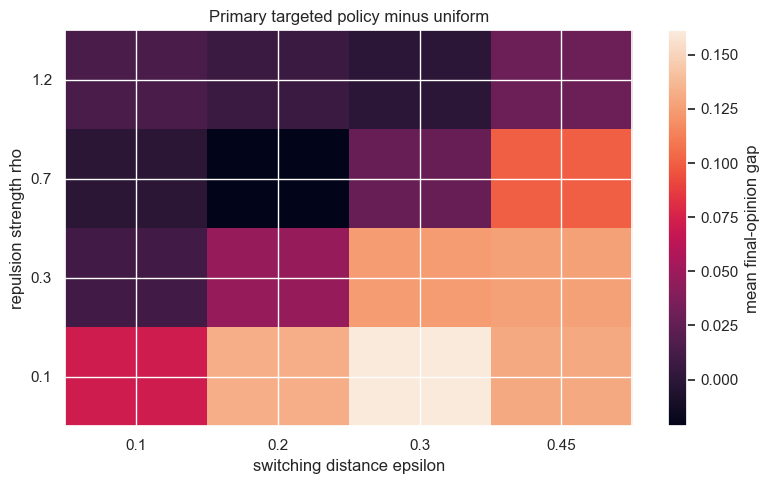

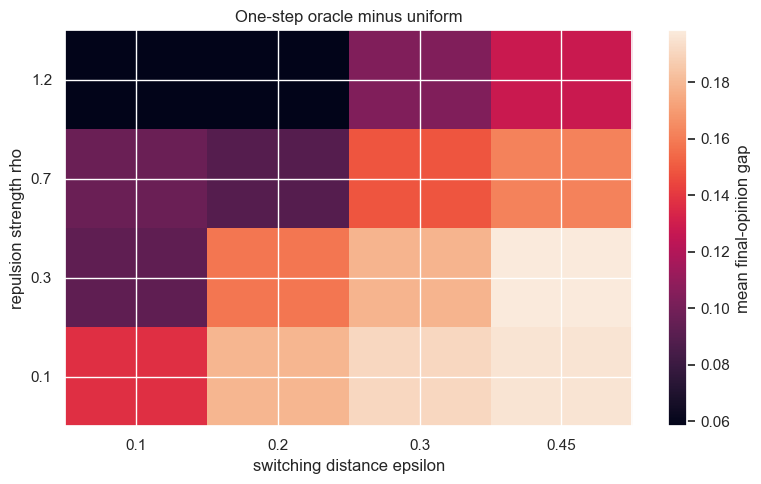

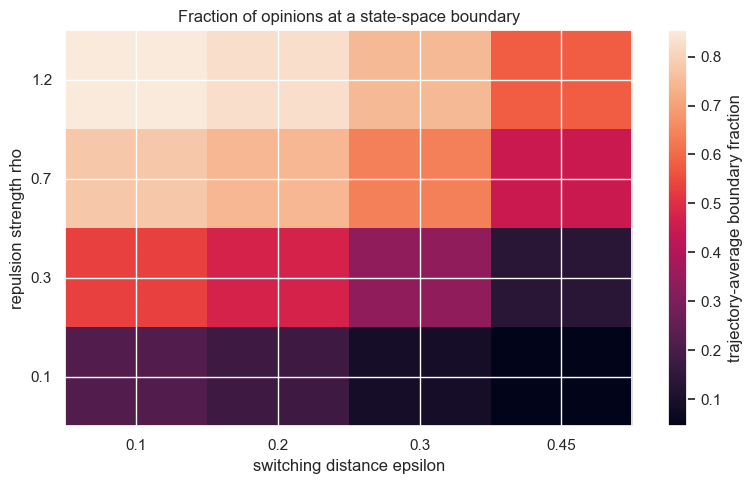

In [11]:

for value_column, title in [
    (
        "primary_vs_uniform_mean",
        "Primary targeted policy minus uniform",
    ),
    (
        "model_aware_vs_uniform_mean",
        "One-step oracle minus uniform",
    ),
]:
    pivot = ranking_df.pivot(
        index=PARAM_COLUMNS[1],
        columns=PARAM_COLUMNS[0],
        values=value_column,
    ).sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))
    image = ax.imshow(
        pivot.to_numpy(dtype=float),
        aspect="auto",
        origin="lower",
    )
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{value:g}" for value in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{value:g}" for value in pivot.index])
    ax.set_xlabel(PARAMETER_LABELS[PARAM_COLUMNS[0]])
    ax.set_ylabel(PARAMETER_LABELS[PARAM_COLUMNS[1]])
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="mean final-opinion gap")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


boundary_pivot = ranking_df.pivot(
    index=PARAM_COLUMNS[1],
    columns=PARAM_COLUMNS[0],
    values="primary_mean_boundary_fraction",
).sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(
    boundary_pivot.to_numpy(dtype=float),
    aspect="auto",
    origin="lower",
)
ax.set_xticks(np.arange(len(boundary_pivot.columns)))
ax.set_xticklabels([f"{value:g}" for value in boundary_pivot.columns])
ax.set_yticks(np.arange(len(boundary_pivot.index)))
ax.set_yticklabels([f"{value:g}" for value in boundary_pivot.index])
ax.set_xlabel(PARAMETER_LABELS[PARAM_COLUMNS[0]])
ax.set_ylabel(PARAMETER_LABELS[PARAM_COLUMNS[1]])
ax.set_title("Fraction of opinions at a state-space boundary")
fig.colorbar(image, ax=ax, label="trajectory-average boundary fraction")
fig.tight_layout()
plt.show()
plt.close(fig)


## Trajectories for the highest-ranked configurations

Each curve is the median across paired trials; the shaded band is the interquartile range.

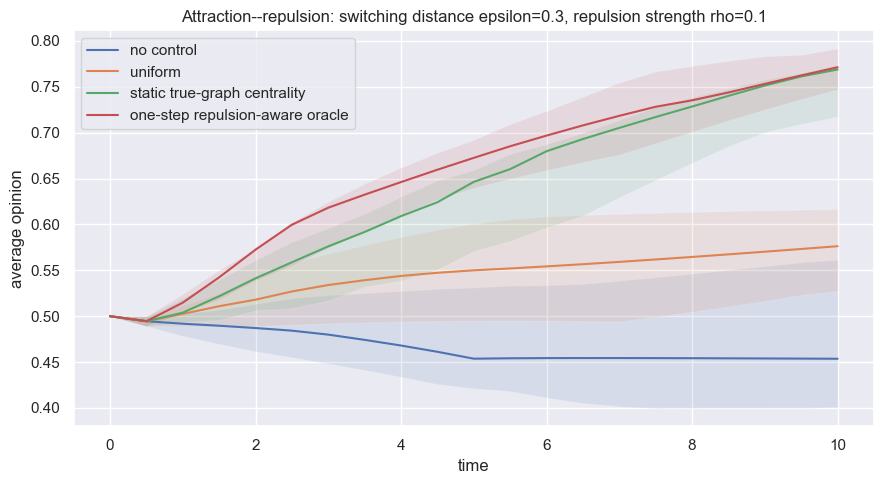

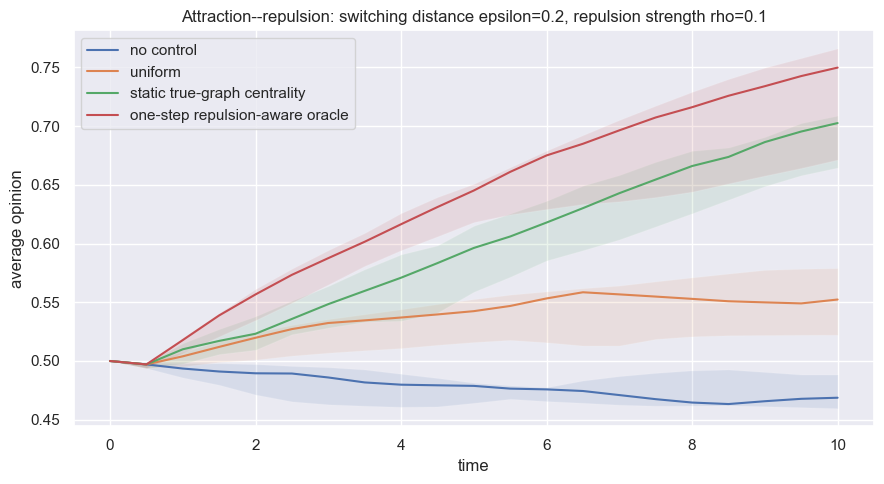

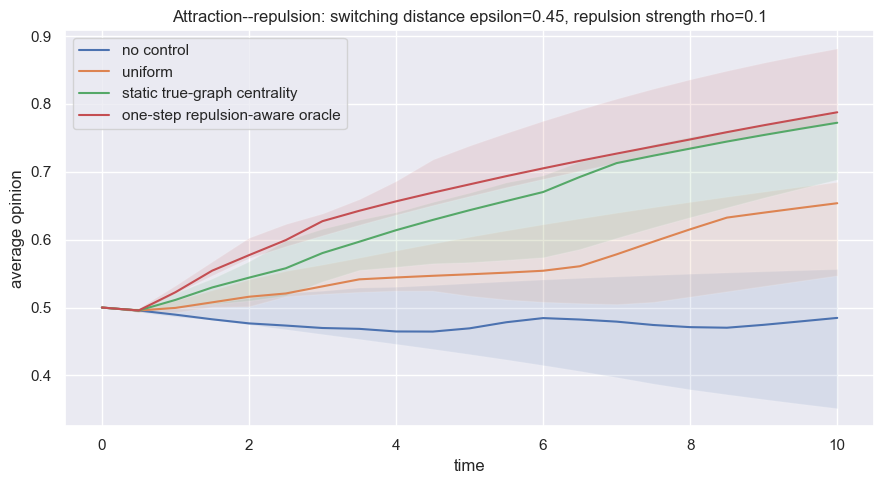

In [12]:

top_config_rows = ranking_df.head(TOP_CONFIGS_TO_PLOT)

for _, config_row in top_config_rows.iterrows():
    mask = np.ones(len(trajectories_df), dtype=bool)
    title_parts = []

    for name in PARAM_COLUMNS:
        value = float(config_row[name])
        mask &= np.isclose(
            trajectories_df[name].to_numpy(dtype=float),
            value,
        )
        title_parts.append(
            f"{PARAMETER_LABELS[name]}={value:g}"
        )

    config_data = trajectories_df[mask]

    fig, ax = plt.subplots(figsize=(9, 5))

    for policy in POLICY_ORDER:
        policy_data = config_data[
            config_data["policy"] == policy
        ]

        aggregated = (
            policy_data.groupby("boundary_index")
            .agg(
                time=("time", "first"),
                median=("mean_opinion", "median"),
                q25=(
                    "mean_opinion",
                    lambda values: values.quantile(0.25),
                ),
                q75=(
                    "mean_opinion",
                    lambda values: values.quantile(0.75),
                ),
            )
            .reset_index()
        )

        ax.plot(
            aggregated["time"],
            aggregated["median"],
            label=POLICY_LABELS[policy],
        )
        ax.fill_between(
            aggregated["time"],
            aggregated["q25"],
            aggregated["q75"],
            alpha=0.12,
        )

    ax.set_xlabel("time")
    ax.set_ylabel("average opinion")
    ax.set_title(
        f"{MODEL_DISPLAY_NAME}: " + ", ".join(title_parts)
    )
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Representative trials for the recommended configuration

These are the worst, median, and best paired targeted-minus-uniform trials.

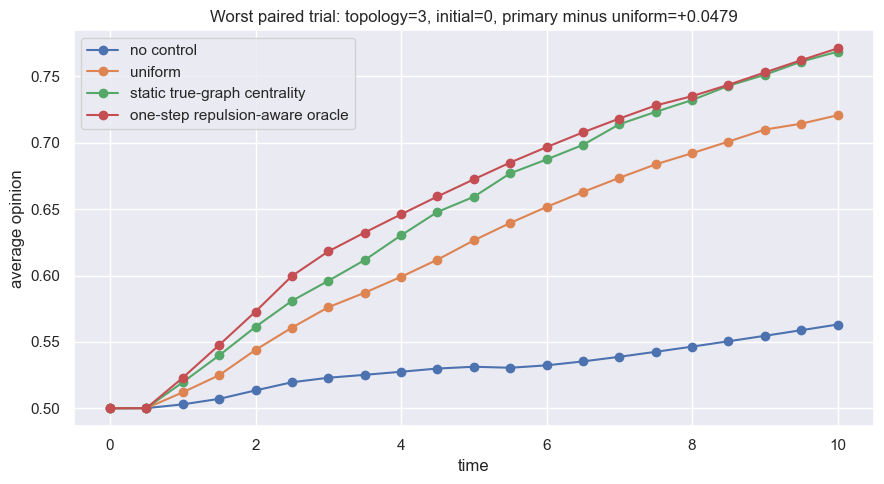

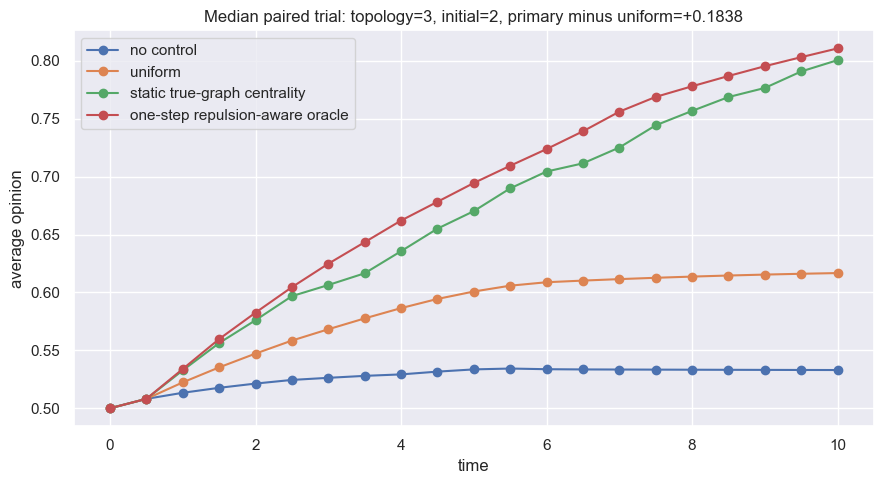

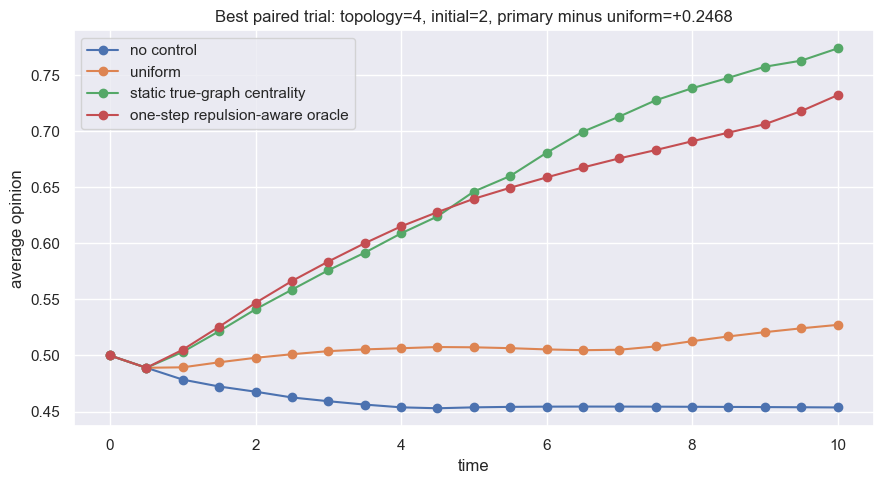

In [13]:

recommended_mask = np.ones(len(paired_df), dtype=bool)
for name, value in recommended_config.items():
    recommended_mask &= np.isclose(
        paired_df[name].to_numpy(dtype=float),
        value,
    )

selected_pairs = paired_df[
    recommended_mask
].sort_values("primary_minus_uniform").reset_index(drop=True)

representative_indices = sorted(
    {
        0,
        len(selected_pairs) // 2,
        len(selected_pairs) - 1,
    }
)

for row_index in representative_indices:
    pair_row = selected_pairs.iloc[row_index]
    topology_seed = int(pair_row["topology_seed"])
    initial_seed = int(pair_row["initial_seed"])
    gap = float(pair_row["primary_minus_uniform"])

    trial_mask = (
        (trajectories_df["topology_seed"] == topology_seed)
        & (trajectories_df["initial_seed"] == initial_seed)
    )
    for name, value in recommended_config.items():
        trial_mask &= np.isclose(
            trajectories_df[name].to_numpy(dtype=float),
            value,
        )

    trial_data = trajectories_df[trial_mask]

    fig, ax = plt.subplots(figsize=(9, 5))

    for policy in POLICY_ORDER:
        policy_data = trial_data[
            trial_data["policy"] == policy
        ].sort_values("boundary_index")

        ax.plot(
            policy_data["time"],
            policy_data["mean_opinion"],
            marker="o",
            label=POLICY_LABELS[policy],
        )

    if row_index == 0:
        representative_label = "Worst"
    elif row_index == len(selected_pairs) - 1:
        representative_label = "Best"
    else:
        representative_label = "Median"

    ax.set_xlabel("time")
    ax.set_ylabel("average opinion")
    ax.set_title(
        f"{representative_label} paired trial: "
        f"topology={topology_seed}, initial={initial_seed}, "
        f"primary minus uniform={gap:+.4f}"
    )
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Save results

In [14]:

trials_path = RESULTS_DIR / f"{STUDY_NAME}_trials.csv"
trajectories_path = RESULTS_DIR / f"{STUDY_NAME}_trajectories.csv"
paired_path = RESULTS_DIR / f"{STUDY_NAME}_paired.csv"
ranking_path = RESULTS_DIR / f"{STUDY_NAME}_ranking.csv"
failed_path = RESULTS_DIR / f"{STUDY_NAME}_failures.csv"
manifest_path = RESULTS_DIR / f"{STUDY_NAME}_manifest.json"

trials_df.to_csv(trials_path, index=False)
trajectories_df.to_csv(trajectories_path, index=False)
paired_df.to_csv(paired_path, index=False)
ranking_df.to_csv(ranking_path, index=False)
failed_df.to_csv(failed_path, index=False)

manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "study_name": STUDY_NAME,
    "model_kind": MODEL_KIND,
    "dynamics_model": DYNAMICS_MODEL,
    "parameter_configs": PARAM_CONFIGS,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "omega": OMEGA,
    "u_bar": U_BAR,
    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "total_controlled_budget": TOTAL_CONTROLLED_BUDGET,
    "budget_per_controlled_campaign": B_CAMPAIGN,
    "zero_first_campaign": ZERO_FIRST_CAMPAIGN,
    "policies": POLICY_ORDER,
    "primary_policy": PRIMARY_POLICY,
    "minimum_target_win_rate": MIN_TARGET_WIN_RATE,
    "recommended_config": recommended_config,
    "quick_run": QUICK_RUN,
}

manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print("Saved:")
for path in [
    trials_path,
    trajectories_path,
    paired_path,
    ranking_path,
    failed_path,
    manifest_path,
]:
    print(" -", path)

print("\nRecommended configuration:", recommended_config)


Saved:
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_repulsion_parameter_screen\repulsion_parameter_screen_trials.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_repulsion_parameter_screen\repulsion_parameter_screen_trajectories.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_repulsion_parameter_screen\repulsion_parameter_screen_paired.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_repulsion_parameter_screen\repulsion_parameter_screen_ranking.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_repulsion_parameter_screen\repulsion_parameter_screen_failures.csv
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_28_repulsion_parameter_screen\repulsion_parameter_

## Next step

Confirm the best two or three configurations on fresh topology and initial-state seeds before fixing the paper parameter.